In [1]:
#got my dataset from geo, now we will import all libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [2]:
#uploading dataset, leave it zipped guys
from google.colab import files

uploaded = files.upload()

Saving GSE44076_series_matrix.txt.gz to GSE44076_series_matrix.txt.gz


In [4]:
import gzip

with gzip.open("GSE44076_series_matrix.txt.gz", "rt") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "ID_REF" in line:
        print("Found at line:", i)
        print(line[:300])
        break

Found at line: 81
"ID_REF"	"GSM1077598"	"GSM1077599"	"GSM1077600"	"GSM1077601"	"GSM1077602"	"GSM1077603"	"GSM1077604"	"GSM1077605"	"GSM1077606"	"GSM1077607"	"GSM1077608"	"GSM1077609"	"GSM1077610"	"GSM1077611"	"GSM1077612"	"GSM1077613"	"GSM1077614"	"GSM1077615"	"GSM1077616"	"GSM1077617"	"GSM1077618"	"GSM1077619"	"GSM1


In [5]:
import pandas as pd

expr = pd.read_csv(
    "GSE44076_series_matrix.txt.gz",
    sep="\t",
    skiprows=81
)

expr.head()

,ID_REF,GSM1077598,GSM1077599,GSM1077600,GSM1077601,GSM1077602,GSM1077603,GSM1077604,GSM1077605,GSM1077606,...,GSM1077834,GSM1077835,GSM1077836,GSM1077837,GSM1077838,GSM1077839,GSM1077840,GSM1077841,GSM1077842,GSM1077843
0,11715100_at,3.6599,2.5712,3.3174,3.1835,2.9949,3.4481,3.1692,3.5142,2.7073,...,3.2312,4.4599,3.8468,3.8416,4.2620,2.7624,2.5775,3.1441,4.8256,3.3535
1,11715101_s_at,4.1524,4.1879,4.1040,4.3635,4.5227,4.1203,4.2486,4.1462,3.8748,...,3.8795,5.7232,4.7099,4.0111,4.9795,3.7898,3.7737,4.3357,5.4895,4.4803
2,11715102_x_at,3.3896,3.1228,3.2434,3.1175,3.3627,2.8233,3.4594,3.1960,3.1082,...,3.3990,5.1110,4.2058,3.2759,4.4833,3.0972,2.7807,3.4050,4.4170,3.2669
3,11715103_x_at,3.8929,3.7299,4.1048,3.3426,3.3376,3.0590,3.2893,3.2290,2.9375,...,3.7911,3.1532,4.2702,3.4329,3.5422,4.3038,3.2338,3.4187,4.6358,4.1998
4,11715104_s_at,7.3799,7.7642,6.4705,7.0046,6.9029,6.1424,6.5051,6.4659,6.6958,...,2.6693,2.6769,2.7843,2.6698,2.8176,3.0904,2.6377,3.0226,2.7754,2.3838


In [7]:
expr.shape
expr.tail()

,ID_REF,GSM1077598,GSM1077599,GSM1077600,GSM1077601,GSM1077602,GSM1077603,GSM1077604,GSM1077605,GSM1077606,...,GSM1077834,GSM1077835,GSM1077836,GSM1077837,GSM1077838,GSM1077839,GSM1077840,GSM1077841,GSM1077842,GSM1077843
49382,AFFX-ThrX-M_at,5.9995,6.2646,6.3628,5.1356,6.1207,7.1956,6.5755,5.2463,6.3274,...,5.8020,6.3594,5.3759,5.6525,5.3199,5.9032,5.8160,5.1489,6.0431,5.6033
49383,AFFX-TrpnX-3_at,2.1907,1.9371,2.1923,2.0068,2.1847,2.2407,1.8940,2.0712,1.9048,...,1.9564,2.0278,2.2097,2.1716,1.9210,2.0684,1.9110,2.1146,2.0207,2.0328
49384,AFFX-TrpnX-5_at,2.1474,2.2677,2.2233,2.2773,2.3030,2.2770,2.0634,2.3013,2.2326,...,1.9982,2.0774,2.1296,2.0454,2.0803,1.9758,2.1660,2.0619,2.2717,2.2460
49385,AFFX-TrpnX-M_at,2.1102,2.3093,2.2221,2.2656,2.1275,2.4722,2.4505,2.1832,2.1634,...,2.1991,2.1269,2.2233,2.2543,2.2014,2.2050,2.0183,2.0312,2.2361,2.1781
49386,!series_matrix_table_end,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
expr = expr[
    expr["ID_REF"] != "!series_matrix_table_end"
]

In [9]:
expr = expr.set_index("ID_REF")

expr = expr.T

expr.head()

ID_REF,11715100_at,11715101_s_at,11715102_x_at,11715103_x_at,11715104_s_at,11715105_at,11715106_x_at,11715107_s_at,11715108_x_at,11715109_at,...,AFFX-r2-TagO-3_at,AFFX-r2-TagO-5_at,AFFX-r2-TagQ-3_at,AFFX-r2-TagQ-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM1077598,3.6599,4.1524,3.3896,3.8929,7.3799,2.0732,2.8276,2.6345,2.5165,2.4795,...,1.9475,2.1732,2.3173,2.0892,7.0313,4.8902,5.9995,2.1907,2.1474,2.1102
GSM1077599,2.5712,4.1879,3.1228,3.7299,7.7642,2.3151,2.8944,2.4020,2.5873,2.2066,...,1.9056,1.9503,2.0665,2.0585,7.3201,5.2443,6.2646,1.9371,2.2677,2.3093
GSM1077600,3.3174,4.1040,3.2434,4.1048,6.4705,2.1824,2.7407,2.4271,2.5785,2.6003,...,2.5070,2.4232,2.4662,2.2127,8.0270,5.8140,6.3628,2.1923,2.2233,2.2221
GSM1077601,3.1835,4.3635,3.1175,3.3426,7.0046,2.1961,2.4710,2.2932,2.3527,2.4741,...,2.0228,2.7202,2.4453,2.3259,7.1081,4.7067,5.1356,2.0068,2.2773,2.2656
GSM1077602,2.9949,4.5227,3.3627,3.3376,6.9029,2.5087,2.8609,2.4833,2.3683,2.3747,...,1.9309,2.1284,2.6587,2.4271,7.7353,5.2432,6.1207,2.1847,2.3030,2.1275


In [10]:
expr.shape

(246, 49386)

In [13]:
import gzip

with gzip.open("GSE44076_series_matrix.txt.gz", "rt") as f:
    lines = f.readlines()

sample_type_line = None

for line in lines[:81]:
    if line.startswith("!Sample_characteristics_ch1") and "sample type:" in line:
        sample_type_line = line
        break

sample_types = [
    x.replace('"','').replace('sample type: ','')
    for x in sample_type_line.strip().split("\t")[1:]
]

len(sample_types)

246

In [14]:
y = [
    1 if x == "Tumor" else 0
    for x in sample_types
]

In [15]:
from collections import Counter

Counter(y)

Counter({0: 148, 1: 98})

In [16]:
expr = expr.apply(pd.to_numeric)

In [17]:
expr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, GSM1077598 to GSM1077843
Columns: 49386 entries, 11715100_at to AFFX-TrpnX-M_at
dtypes: float64(49386)
memory usage: 92.7+ MB


In [18]:
import pandas as pd

pd.Series(y).value_counts()

,count
0,148
1,98


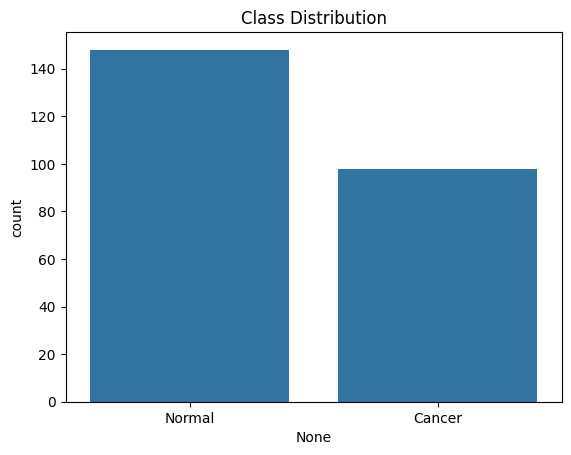

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x=pd.Series(y).map({
        0:"Normal",
        1:"Cancer"
    })
)

plt.title("Class Distribution")
plt.show()

In [20]:
gene_variance = expr.var()

top500 = gene_variance.nlargest(500).index

X = expr[top500]

In [21]:
expr.shape

(246, 49386)

# Colon Cancer Gene Expression Classification

## Dataset

GSE44076 (GEO)

This dataset contains gene expression profiles from:

- Healthy colon mucosa samples
- Adjacent normal colon tissue
- Colon tumor tissue

For this study:

- Healthy + Adjacent Normal → Normal class
- Tumor → Cancer class

Total samples: 246
Total gene probes: 49,386


In [23]:
import pandas as pd

label_names = pd.Series(y).map({
    0: "Normal",
    1: "Cancer"
})

label_names.value_counts()

,count
Normal,148
Cancer,98


In [25]:
gene_variance = expr.var() #we will lower our useful data

top500 = gene_variance.nlargest(500).index

X = expr[top500]

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

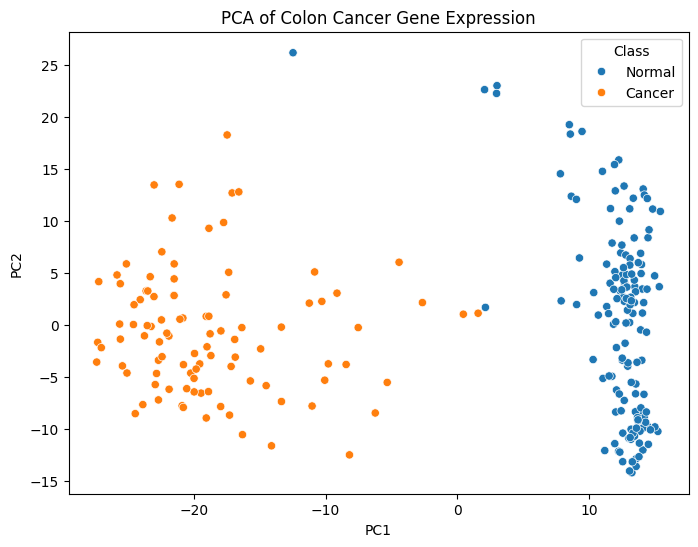

In [29]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Class": label_names
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Class"
)

plt.title("PCA of Colon Cancer Gene Expression")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(lr_acc)

1.0


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

0.98


In [34]:
from sklearn.svm import SVC

svm = SVC(
    probability=True
)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(
    y_test,
    svm_pred
)

print(svm_acc)

1.0


In [35]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy":[
        lr_acc,
        rf_acc,
        svm_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.00
1,Random Forest,0.98
2,SVM,1.00


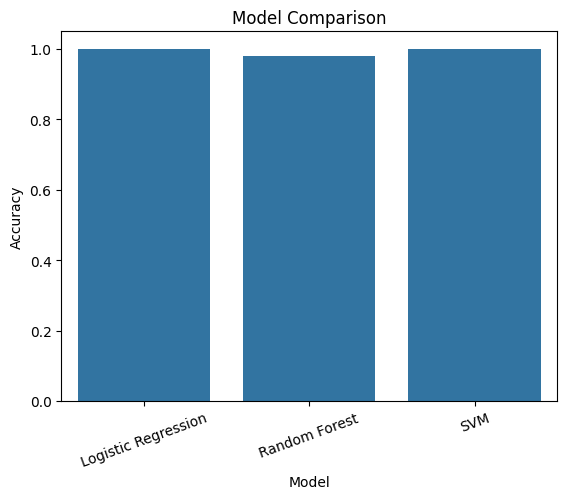

In [36]:
sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

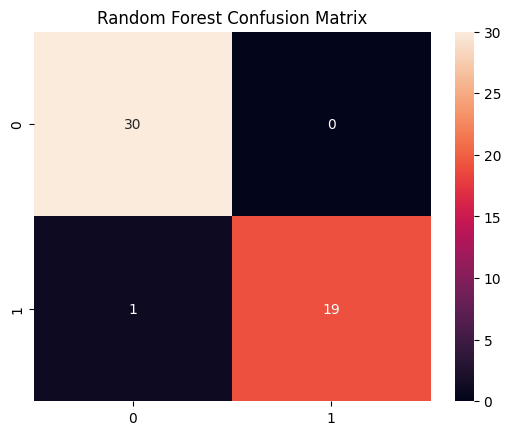

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import roc_curve, auc

In [39]:
rf_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    rf_prob
)

roc_auc = auc(
    fpr,
    tpr
)

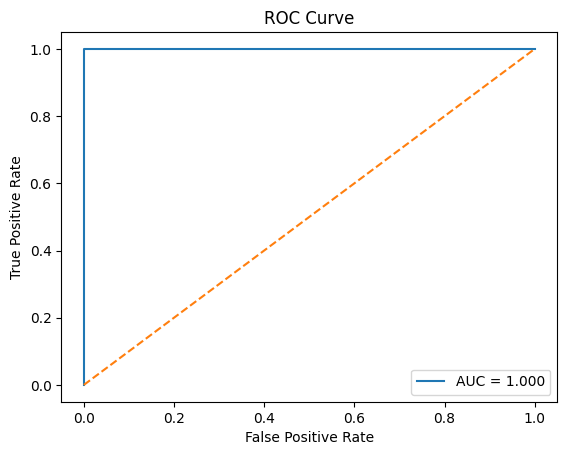

In [40]:
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.title("ROC Curve")
plt.show()

In [41]:
importance = pd.Series(
    rf.feature_importances_,
    index=top500
)

In [42]:
top20 = importance.nlargest(20)

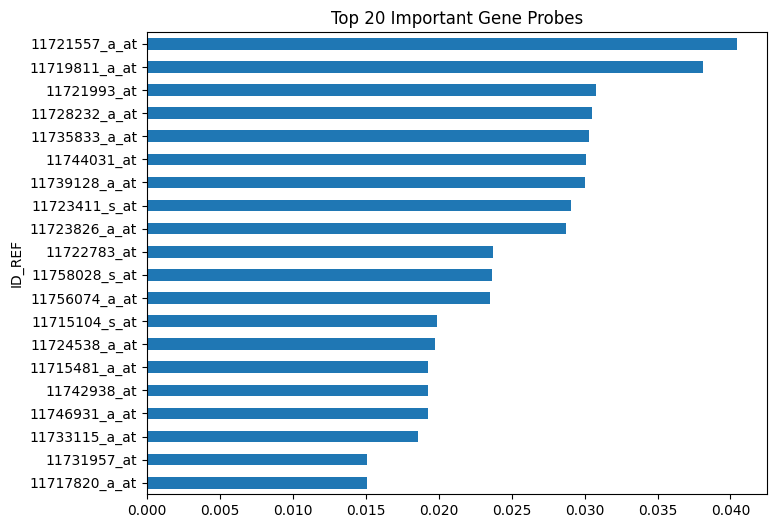

In [43]:
plt.figure(figsize=(8,6))

top20.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Important Gene Probes")
plt.show()